# High-Value Fleet Segment Summary
**Core Pattern:** Selective Scan, Filter, Derive, & Bounded Aggregate

This suite scans the taxi fact files, applies high-value-trip sanity filters, derives a distance band, and returns a small native summary table rather than millions of filtered rows.

In [1]:
import sys, os

try:
    import datapunk  # noqa: F401
except ImportError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

os.environ["DAFT_PROGRESS_BAR"] = "0"
import plotly.io as pio

pio.renderers.default = "svg"

from datapunk.reporter import DatapunkReporter

RAM_CAP = 1024  # in MB

reporter = DatapunkReporter(
    small_months=1,
    large_cap_mb=RAM_CAP,
    with_lookup=False,
)

  ⚙ unifying schema across 24 files (20 cols)…
     ✅ unified files cached.


Datapunk Environment
----------------------------------------------------
  OS:        Darwin 25.3.0
  CPU:       Apple M1 Pro (8 cores)
  RAM:       16.0 GB
  Python:    v3.14.6
  Small run: 1 month, uncapped, 5 iter + 1 warmup
  Large run: 24 months, cap = 1024 MB (physical RSS), 1 iter + 0 warmup
----------------------------------------------------


## Analytics Functions

In [2]:
# High-value segment summary with bounded output.
#
# The analytic question: among plausible long-distance, high-fare yellow-taxi
# trips, which distance bands drive trip volume, gross revenue, and fare density?
# Every engine still scans and filters the full input, but the materialized output
# is one summary row per distance band.
COLS = ["trip_distance", "passenger_count", "fare_amount", "total_amount"]
OUT_COLS = [
    "distance_band",
    "band_order",
    "trip_count",
    "gross_revenue",
    "avg_total_fare",
    "avg_trip_distance",
    "revenue_per_mile",
    "avg_passenger_count",
]
BAND_LABELS = ["10-15 mi", "15-25 mi", "25-50 mi", "50-100 mi"]
BAND_ORDER = {label: i + 1 for i, label in enumerate(BAND_LABELS)}
PARQUET_FILTERS = [
    [
        ("trip_distance", ">", 10.0),
        ("trip_distance", "<", 100.0),
        ("fare_amount", ">", 40.0),
        ("fare_amount", "<", 500.0),
        ("total_amount", ">", 0.0),
        ("passenger_count", ">=", 1),
        ("passenger_count", "<=", 6),
    ]
]


def _empty_summary_pandas():
    import pandas as pd

    return pd.DataFrame(
        {
            "distance_band": pd.Series(dtype="string"),
            "band_order": pd.Series(dtype="int64"),
            "trip_count": pd.Series(dtype="int64"),
            "gross_revenue": pd.Series(dtype="float64"),
            "avg_total_fare": pd.Series(dtype="float64"),
            "avg_trip_distance": pd.Series(dtype="float64"),
            "revenue_per_mile": pd.Series(dtype="float64"),
            "avg_passenger_count": pd.Series(dtype="float64"),
        }
    )


def _exact_mask_pandas(df):
    return (
        (df["trip_distance"] > 10.0)
        & (df["trip_distance"] < 100.0)
        & (df["fare_amount"] > 40.0)
        & (df["fare_amount"] < 500.0)
        & (df["total_amount"] > 0.0)
        & (df["passenger_count"] >= 1)
        & (df["passenger_count"] <= 6)
    )


def _add_distance_band_pandas(df):
    import pandas as pd

    out = df.copy()
    out["distance_band"] = pd.cut(
        out["trip_distance"],
        bins=[10.0, 15.0, 25.0, 50.0, 100.0],
        labels=BAND_LABELS,
        right=False,
    ).astype("string")
    out["band_order"] = out["distance_band"].map(BAND_ORDER).astype("int64")
    return out


def _finalize_summary_pandas(grouped):
    if grouped is None or len(grouped) == 0:
        return _empty_summary_pandas()
    out = grouped.copy()
    out["revenue_per_mile"] = out["gross_revenue"] / out["total_distance"]
    return (
        out[OUT_COLS]
        .sort_values("band_order", kind="mergesort")
        .reset_index(drop=True)
        .copy()
    )


def _polars_distance_band_expr(pl):
    return (
        pl.when(pl.col("trip_distance") < 15.0)
        .then(pl.lit("10-15 mi"))
        .when(pl.col("trip_distance") < 25.0)
        .then(pl.lit("15-25 mi"))
        .when(pl.col("trip_distance") < 50.0)
        .then(pl.lit("25-50 mi"))
        .otherwise(pl.lit("50-100 mi"))
        .alias("distance_band")
    )


def _polars_band_order_expr(pl):
    return (
        pl.when(pl.col("trip_distance") < 15.0)
        .then(pl.lit(1))
        .when(pl.col("trip_distance") < 25.0)
        .then(pl.lit(2))
        .when(pl.col("trip_distance") < 50.0)
        .then(pl.lit(3))
        .otherwise(pl.lit(4))
        .alias("band_order")
    )


def _duckdb_materialize(query, params, *, capped=False):
    import duckdb
    import uuid
    from datapunk.fingerprint import DuckDBTableResult

    con = duckdb.connect()
    if capped:
        con.execute(f"SET memory_limit='{int(RAM_CAP * 0.8)}MB'")

    table = f"datapunk_result_{uuid.uuid4().hex}"
    con.execute(f"CREATE TEMP TABLE {table} AS {query}", params)
    return DuckDBTableResult(con=con, table=table)


def scan_filter_summary_pandas(file_path):
    import pandas as pd

    df = pd.concat(
        [
            pd.read_parquet(
                p,
                columns=COLS,
                filters=PARQUET_FILTERS,
                engine="pyarrow",
            )
            for p in file_path
        ],
        ignore_index=True,
    )
    df = df.loc[_exact_mask_pandas(df), COLS]
    if df.empty:
        result = _empty_summary_pandas()
    else:
        df = _add_distance_band_pandas(df)
        grouped = (
            df.groupby(["distance_band", "band_order"], sort=True, observed=True)
            .agg(
                trip_count=("total_amount", "count"),
                gross_revenue=("total_amount", "sum"),
                avg_total_fare=("total_amount", "mean"),
                avg_trip_distance=("trip_distance", "mean"),
                total_distance=("trip_distance", "sum"),
                avg_passenger_count=("passenger_count", "mean"),
            )
            .reset_index()
        )
        result = _finalize_summary_pandas(grouped)
    return result, {"engine": pd.__name__, "version": pd.__version__}


def scan_filter_summary_polars(file_path):
    import polars as pl

    lf = (
        pl.scan_parquet(file_path)
        .filter(
            (pl.col("trip_distance") > 10.0)
            & (pl.col("trip_distance") < 100.0)
            & (pl.col("fare_amount") > 40.0)
            & (pl.col("fare_amount") < 500.0)
            & (pl.col("total_amount") > 0.0)
            & (pl.col("passenger_count") >= 1)
            & (pl.col("passenger_count") <= 6)
        )
        .select(COLS)
        .with_columns([_polars_distance_band_expr(pl), _polars_band_order_expr(pl)])
        .group_by(["distance_band", "band_order"])
        .agg(
            [
                pl.len().alias("trip_count"),
                pl.col("total_amount").sum().alias("gross_revenue"),
                pl.col("total_amount").mean().alias("avg_total_fare"),
                pl.col("trip_distance").mean().alias("avg_trip_distance"),
                pl.col("trip_distance").sum().alias("total_distance"),
                pl.col("passenger_count").mean().alias("avg_passenger_count"),
            ]
        )
        .with_columns(
            (pl.col("gross_revenue") / pl.col("total_distance")).alias(
                "revenue_per_mile"
            )
        )
        .select(OUT_COLS)
        .sort("band_order")
    )
    result = lf.collect()
    return result, {"engine": pl.__name__, "version": pl.__version__}


def scan_filter_summary_polars_streaming(file_path):
    import polars as pl

    lf = (
        pl.scan_parquet(file_path)
        .filter(
            (pl.col("trip_distance") > 10.0)
            & (pl.col("trip_distance") < 100.0)
            & (pl.col("fare_amount") > 40.0)
            & (pl.col("fare_amount") < 500.0)
            & (pl.col("total_amount") > 0.0)
            & (pl.col("passenger_count") >= 1)
            & (pl.col("passenger_count") <= 6)
        )
        .select(COLS)
        .with_columns([_polars_distance_band_expr(pl), _polars_band_order_expr(pl)])
        .group_by(["distance_band", "band_order"])
        .agg(
            [
                pl.len().alias("trip_count"),
                pl.col("total_amount").sum().alias("gross_revenue"),
                pl.col("total_amount").mean().alias("avg_total_fare"),
                pl.col("trip_distance").mean().alias("avg_trip_distance"),
                pl.col("trip_distance").sum().alias("total_distance"),
                pl.col("passenger_count").mean().alias("avg_passenger_count"),
            ]
        )
        .with_columns(
            (pl.col("gross_revenue") / pl.col("total_distance")).alias(
                "revenue_per_mile"
            )
        )
        .select(OUT_COLS)
        .sort("band_order")
    )
    result = lf.collect(engine="streaming")
    return result, {"engine": f"{pl.__name__}-streaming", "version": pl.__version__}


def _duckdb_summary_query():
    return """
        WITH filtered AS (
            SELECT
                CASE
                    WHEN trip_distance < 15.0 THEN '10-15 mi'
                    WHEN trip_distance < 25.0 THEN '15-25 mi'
                    WHEN trip_distance < 50.0 THEN '25-50 mi'
                    ELSE '50-100 mi'
                END AS distance_band,
                CASE
                    WHEN trip_distance < 15.0 THEN 1
                    WHEN trip_distance < 25.0 THEN 2
                    WHEN trip_distance < 50.0 THEN 3
                    ELSE 4
                END AS band_order,
                trip_distance,
                passenger_count,
                total_amount
            FROM read_parquet($files)
            WHERE trip_distance > 10.0 AND trip_distance < 100.0
              AND fare_amount > 40.0 AND fare_amount < 500.0
              AND total_amount > 0.0
              AND passenger_count >= 1 AND passenger_count <= 6
        ), grouped AS (
            SELECT
                distance_band,
                band_order,
                COUNT(*) AS trip_count,
                SUM(total_amount) AS gross_revenue,
                AVG(total_amount) AS avg_total_fare,
                AVG(trip_distance) AS avg_trip_distance,
                SUM(trip_distance) AS total_distance,
                AVG(passenger_count) AS avg_passenger_count
            FROM filtered
            GROUP BY 1, 2
        )
        SELECT
            distance_band,
            band_order,
            trip_count,
            gross_revenue,
            avg_total_fare,
            avg_trip_distance,
            gross_revenue / NULLIF(total_distance, 0.0) AS revenue_per_mile,
            avg_passenger_count
        FROM grouped
        ORDER BY band_order
    """


def scan_filter_summary_duckdb(file_path):
    import duckdb

    result = _duckdb_materialize(
        _duckdb_summary_query(), {"files": list(map(str, file_path))}
    )
    return result, {"engine": duckdb.__name__, "version": duckdb.__version__}


def scan_filter_summary_duckdb_capped(file_path):
    import duckdb

    result = _duckdb_materialize(
        _duckdb_summary_query(), {"files": list(map(str, file_path))}, capped=True
    )
    return result, {
        "engine": f"{duckdb.__name__}-capped",
        "version": duckdb.__version__,
    }


def scan_filter_summary_dask(file_path):
    import dask
    import dask.dataframe as dd
    import pandas as pd

    df = dd.read_parquet(file_path, columns=COLS, filters=PARQUET_FILTERS)
    df = df.loc[_exact_mask_pandas(df), COLS]

    meta = df._meta.copy()
    meta["distance_band"] = pd.Series(dtype="string")
    meta["band_order"] = pd.Series(dtype="int64")
    df = df.map_partitions(_add_distance_band_pandas, meta=meta)

    grouped = (
        df.groupby(["distance_band", "band_order"])
        .agg(
            trip_count=("total_amount", "count"),
            gross_revenue=("total_amount", "sum"),
            avg_total_fare=("total_amount", "mean"),
            avg_trip_distance=("trip_distance", "mean"),
            total_distance=("trip_distance", "sum"),
            avg_passenger_count=("passenger_count", "mean"),
        )
        .reset_index()
        .compute()
    )
    result = _finalize_summary_pandas(grouped)
    return result, {"engine": dask.__name__, "version": dask.__version__}


def scan_filter_summary_daft(file_path):
    import daft
    from daft import col

    df = daft.read_parquet(list(file_path)).select(*COLS)
    df = df.filter(
        (df["trip_distance"] > 10.0)
        & (df["trip_distance"] < 100.0)
        & (df["fare_amount"] > 40.0)
        & (df["fare_amount"] < 500.0)
        & (df["total_amount"] > 0.0)
        & (df["passenger_count"] >= 1)
        & (df["passenger_count"] <= 6)
    )
    df = df.with_column(
        "distance_band",
        daft.sql_expr(
            "CASE WHEN trip_distance < 15.0 THEN '10-15 mi' "
            "WHEN trip_distance < 25.0 THEN '15-25 mi' "
            "WHEN trip_distance < 50.0 THEN '25-50 mi' ELSE '50-100 mi' END"
        ),
    ).with_column(
        "band_order",
        daft.sql_expr(
            "CASE WHEN trip_distance < 15.0 THEN 1 "
            "WHEN trip_distance < 25.0 THEN 2 "
            "WHEN trip_distance < 50.0 THEN 3 ELSE 4 END"
        ),
    )
    result = (
        df.groupby(["distance_band", "band_order"])
        .agg(
            [
                daft.lit(1).count().alias("trip_count"),
                col("total_amount").sum().alias("gross_revenue"),
                col("total_amount").mean().alias("avg_total_fare"),
                col("trip_distance").mean().alias("avg_trip_distance"),
                col("trip_distance").sum().alias("total_distance"),
                col("passenger_count").mean().alias("avg_passenger_count"),
            ]
        )
        .with_column("revenue_per_mile", col("gross_revenue") / col("total_distance"))
        .select(*OUT_COLS)
        .sort("band_order")
        .collect()
    )
    return result, {"engine": daft.__name__, "version": daft.__version__}


ANALYTICS = [
    scan_filter_summary_pandas,
    scan_filter_summary_polars,
    scan_filter_summary_polars_streaming,
    scan_filter_summary_duckdb,
    scan_filter_summary_duckdb_capped,
    scan_filter_summary_dask,
    scan_filter_summary_daft,
]

## Execution & Verification

In [3]:
reporter.run_all(ANALYTICS, target_cols=OUT_COLS)
reporter.export_results(
    suite_id="01",
    title="High-Value Fleet Segment Summary",
    core_pattern="Selective Scan, Filter, Derive, & Bounded Aggregate",
    description=(
        "Long-distance, high-fare trips with passenger and fare sanity bounds, "
        "summarized by distance band. The large run scans the full window but "
        "returns a bounded summary table rather than materializing every matching row."
    ),
)


▶ SMALL run (1 month, cap=none)


    pandas v3.0.3               66 ms  peak 374 MB


    polars v1.41.2              19 ms  peak 318 MB


    polars-streaming v1.41.2      18 ms  peak 330 MB


    duckdb v1.5.4               43 ms  peak 136 MB


...

    polars-streaming v1.41.2     440 ms  peak 571 MB


    duckdb v1.5.4              798 ms  peak 215 MB


    duckdb-capped v1.5.4       618 ms  peak 215 MB


    dask v2026.6.0                OOM  peak 1078 MB


    daft v0.7.15               791 ms  peak 521 MB
    → consistency: ✅ 5 engine(s) agree (4 rows)
📊 exported suite [01] → docs/benchmark_results.json


## Analysis

The small-sample view now tells a segment story rather than plotting every filtered row. It shows which long-trip distance bands contribute the most qualifying trips, which bands generate the most gross fare revenue, and how fare density changes as trips get longer.

**Small-sample high-value segment:** 213,465 qualifying trips generated $18,518,641. The largest volume band was **15-25 mi**; the highest fare-density band was **10-15 mi**.

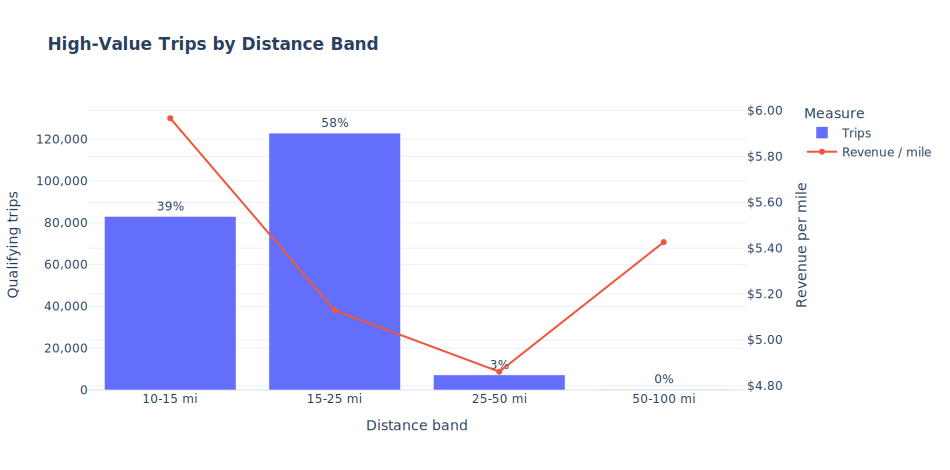

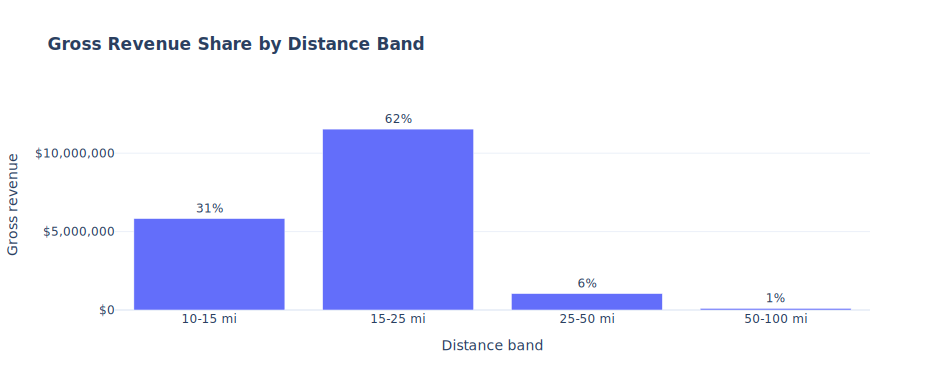

In [4]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Markdown, display

# Visualization is intentionally standardized through pandas on the small run.
reporter.set_analysis_fn(scan_filter_summary_pandas, mode="small")
df = reporter.get_analysis_df(OUT_COLS).sort_values("band_order").copy()

if df.empty:
    display(
        Markdown("No high-value long-distance trips passed the small-sample filters.")
    )
else:
    total_trips = int(df["trip_count"].sum())
    total_revenue = float(df["gross_revenue"].sum())
    volume_band = df.loc[df["trip_count"].idxmax(), "distance_band"]
    yield_band = df.loc[df["revenue_per_mile"].idxmax(), "distance_band"]
    df["trip_share"] = df["trip_count"] / total_trips
    df["revenue_share"] = df["gross_revenue"] / total_revenue

    display(
        Markdown(
            "**Small-sample high-value segment:** "
            f"{total_trips:,} qualifying trips generated ${total_revenue:,.0f}. "
            f"The largest volume band was **{volume_band}**; "
            f"the highest fare-density band was **{yield_band}**."
        )
    )

    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig.add_bar(
        x=df["distance_band"],
        y=df["trip_count"],
        name="Trips",
        text=[f"{s:.0%}" for s in df["trip_share"]],
        textposition="outside",
        secondary_y=False,
    )
    fig.add_scatter(
        x=df["distance_band"],
        y=df["revenue_per_mile"],
        mode="lines+markers",
        name="Revenue / mile",
        secondary_y=True,
    )
    fig.update_layout(
        title="<b>High-Value Trips by Distance Band</b><br><sup>Bars show trip volume; line shows gross revenue per mile</sup>",
        template="plotly_white",
        width=950,
        height=470,
        legend_title_text="Measure",
    )
    fig.update_xaxes(title_text="Distance band")
    fig.update_yaxes(title_text="Qualifying trips", tickformat=",", secondary_y=False)
    fig.update_yaxes(
        title_text="Revenue per mile", tickformat="$,.2f", secondary_y=True
    )
    fig.show()

    fig2 = go.Figure()
    fig2.add_bar(
        x=df["distance_band"],
        y=df["gross_revenue"],
        text=[f"{s:.0%}" for s in df["revenue_share"]],
        textposition="outside",
        name="Gross revenue",
    )
    fig2.update_layout(
        title="<b>Gross Revenue Share by Distance Band</b><br><sup>Small sample; labels show share of qualifying revenue</sup>",
        template="plotly_white",
        width=950,
        height=390,
        yaxis_tickformat="$,",
        xaxis_title="Distance band",
        yaxis_title="Gross revenue",
        showlegend=False,
    )
    fig2.show()

## Performance Comparison

In [5]:
reporter.show_scorecard("Selective Scan Summary Performance")

#### Selective Scan Summary Performance — Single Month · Uncapped

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | 0.0656s | 1.9×       | 374 MB     | —        |
| daft v0.7.15             | 0.0396s | 3.1×       | 170 MB     | —        |
| dask v2026.6.0           | 0.1231s | 1.0×       | 386 MB     | —        |
| duckdb v1.5.4            | 0.0427s | 2.9×       | 136 MB     | —        |
| duckdb-capped v1.5.4     | 0.0446s | 2.8×       | 138 MB     | —        |
| polars v1.41.2           | 0.0194s | 6.4×       | 318 MB     | —        |
| polars-streaming v1.41.2 | 0.0180s | **6.8×**   | 330 MB     | —        |

*✅ 7 engine(s) agree (4 rows)*

#### Selective Scan Summary Performance — Full Window · 1024 MB Cap

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | **OOM** | —          | ≥1024 MB   | ≥1.00    |
| daft v0.7.15             | 0.7913s | 1.0×       | 521 MB     | 0.51     |
| dask v2026.6.0           | **OOM** | —          | ≥1078 MB   | ≥1.05    |
| duckdb v1.5.4            | 0.7975s | 1.0×       | 215 MB     | 0.21     |
| duckdb-capped v1.5.4     | 0.6177s | 1.3×       | 215 MB     | 0.21     |
| polars v1.41.2           | 0.5008s | 1.6×       | 603 MB     | 0.59     |
| polars-streaming v1.41.2 | 0.4400s | **1.8×**   | 571 MB     | 0.56     |

*✅ 5 engine(s) agree (4 rows)*